## 使用Pydantic的好处
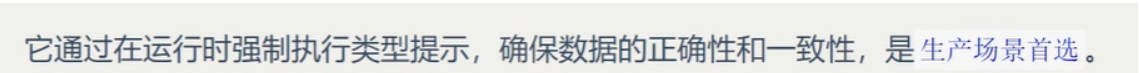 

# 基本使用
## 1.初始化模型
## 注意：ipynb文件里面无法跨文件夹调用文件。

In [2]:
## 1.初始化模型
from langchain.messages import HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field

# 创建模型实例
model = ChatOpenAI(
    model="qwen3-vl:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
    temperature=0.1
)   

In [3]:
class Person(BaseModel):
    """人物信息"""
    name:str = Field(description="姓名")
    age:int = Field(description="年龄")
    job:str = Field(description="职业")

In [ ]:
from rich import print as rprint
# 设置模型输出格式,我们规定它的输出格式位我们的Person类的对象
ret_model = model.with_structured_output(Person)

result = ret_model.invoke("李明是一名30岁的软件工程师")
rprint(result)

Person(name='李明', age=30, job='软件工程师')

In [5]:
print(f"姓名:{result.name},年龄：{result.age},职业：{result.job}")

姓名:李明,年龄：30,职业：软件工程师


In [ ]:
## 1.初始化模型
# from langchain.messages import HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field

# 创建模型实例
model = ChatOpenAI(
    model="qwen3-vl:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
    temperature=0.1
)   

# 定义输出格式
class SentimentAnalysis(BaseModel):
    sentiment: str= Field(description="情感倾向:positive/nagative/neutral")
    confidence: float = Field(description="置信度,0-1之间")
    keywords: list[str]= Field(description="关键词列表")
# 设置模型的输出格式
ret_model = model.with_structured_output(SentimentAnalysis)
txt = "这个课程内容很实用，学到很多知识，强烈推荐!"
result = ret_model.invoke(f"分析以下文本的情感：{txt}")

print(f"类型：{type(result)}")
print(f"情感：{result.sentiment}")
print(f"置信度：{result.confidence}")
print(f"关键词：{result.keywords}")

类型：<class '__main__.SentimentAnalysis'>
情感：<class 'str'>
置信度：<class 'float'>
关键词：<class 'list'>


In [9]:
print(f"类型：{type(result)}")
print(f"情感：{result.sentiment}")
print(f"置信度：{result.confidence}")
print(f"关键词：{result.keywords}")

类型：<class '__main__.SentimentAnalysis'>
情感：positive
置信度：0.95
关键词：['实用', '学到很多知识', '强烈推荐']


# 高级特性
##  2.1可选字段Optional

In [13]:
## 不使用Optional
## 1.初始化模型
from langchain.messages import HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field

# 创建模型实例
model = ChatOpenAI(
    # model="gemma4:latest",
    model="dzgg/gemini-3-pro-preview:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)   

class Person(BaseModel):
    """人物信息"""
    name:str = Field(description="姓名")
    age:int = Field(description="年龄")
    job:str = Field(description="职业")

from rich import print as rprint
# 设置模型输出格式,我们规定它的输出格式位我们的Person类的对象
ret_model = model.with_structured_output(Person)

result = ret_model.invoke("张无忌是一名护士") # 我们特意不传递年龄
rprint(result)    



Person(name='张无忌', age=30, job='护士')

In [12]:
# 作为对比，这里使用Optional
## 不使用Optional
## 1.初始化模型
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from typing import Optional

# 创建模型实例
model = ChatOpenAI(
    # model="qwen3-vl:latest",
    # model="granite3.2:8b",
    model="dzgg/gemini-3-pro-preview:latest",
    # model="mistral-nemo:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)   

class Person(BaseModel):
    """人物信息"""
    name:str = Field(description="姓名")
    age:Optional[int] = Field(description="年龄") #设置可选字段
    job:str = Field(description="职业")

from rich import print as rprint
# 设置模型输出格式,我们规定它的输出格式位我们的Person类的对象
ret_model = model.with_structured_output(Person)

result = ret_model.invoke("马云是一名电商老板") # 我们特意不传递年龄
rprint(result)

Person(name='马云', age=58, job='阿里巴巴创始人、常务董事兼CEO')

### 2.2默认值


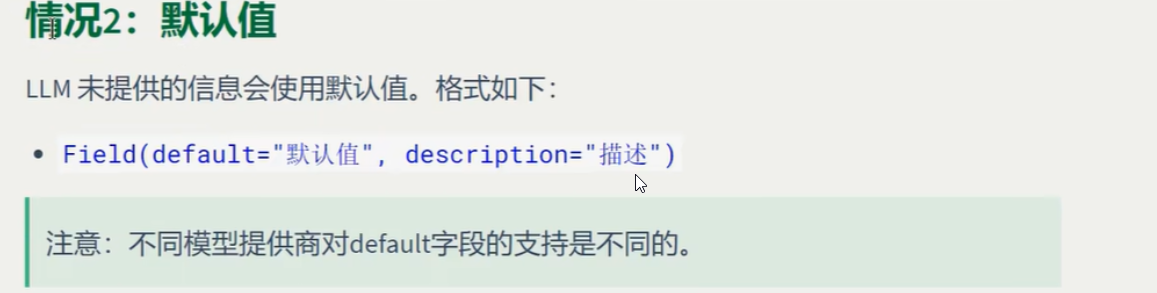

In [14]:
# 默认值
## 1.初始化模型
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from typing import Optional

# 创建模型实例
model = ChatOpenAI(
    # model="gemma4:latest",
    # model="pdurugyan/qwen3.5-9b-deepseek-v4-flash-Q4_K_M-v_2:latest",
    # model="mistral-nemo:latest",
    model="dzgg/gemini-3-pro-preview:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)

class Person(BaseModel):
    """人物信息"""
    name:str = Field(description="姓名")
    age:int = Field(default=19,description="年龄") #设置可选字段,qwen模型不支持默认值？gemma4也不支持？
    job:str = Field(description="职业")

from rich import print as rprint
# 设置模型输出格式,我们规定它的输出格式位我们的Person类的对象
ret_model = model.with_structured_output(Person)

result = ret_model.invoke("Jack是一名司机") # 我们特意不传递年龄
rprint(result)

Person(name='Jack', age=40, job='司机')

In [15]:
# 默认值
## 1.初始化模型
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from typing import Optional
from rich import print as rprint

# 创建模型实例
model = ChatOpenAI(
    # model="mistral-nemo:latest",
    model="dzgg/gemini-3-pro-preview:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)

class Config(BaseModel):
     timeout: Optional[int] = Field(30,description="超时时间(单位秒)")
     retry: bool = Field(False,description="是否支持重试")
     max_attempts: int = Field(6,description="最大重试次数")

ret_model = model.with_structured_output(Config)
msg = ret_model.invoke("配置要求：支持重试，最多重试5次")
rprint(msg)


Config(timeout=30, retry=True, max_attempts=3)

In [16]:
# 默认值
## 1.初始化模型
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from typing import Optional
from rich import print as rprint

# 创建模型实例
model = ChatOpenAI(
    # model="mistral-nemo:latest",
    model="dzgg/gemini-3-pro-preview:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)

class Product(BaseModel):
     """产品信息"""
     name: str = Field(description="产品名称")
     price: float = Field(description="价格")
     description: Optional[str] = Field(description="产品描述")
     stock: int = Field(default=100,description="库存")

st_model = model.with_structured_output(Product)
resp1 = st_model.invoke("Iphone15, 售价6000,最新智能手机,库存80台")
rprint(resp1)
print("===================================")
resp2 = st_model.invoke("MacBook pro, 售价12000 ")
rprint(resp2)


Product(name='Iphone15', price=6000.0, description='当前 latest smartphone,库存如下', stock=80)

Product(
    name='macBook Pro',
    price=12000.0,
    description='High-performance laptop with a 14-inch or 16-inch display, up to 10th Gen Intel Core i9 processor,
up to 64GB RAM, and up to 8TB SSD storage.',
    stock=0
)

# 2.3枚举类型

In [19]:
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from enum import Enum
from rich import print as rprint

# 创建模型实例
model = ChatOpenAI(
    # model="mistral-nemo:latest",
    model="dzgg/gemini-3-pro-preview:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)

class Priority(str, Enum):
    LOW = "低"
    MEDIUM = "中"
    HIGH = "高"
class Task(BaseModel):
    title:str
    priority: Priority

st_model = model.with_structured_output(Task)
msg = st_model.invoke("任务名称：'系统更新',优先级：高")
rprint(msg)




Task(title='系统更新', priority=<Priority.HIGH: '高'>)

In [22]:
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from enum import Enum
from rich import print as rprint

# 创建模型实例
model = ChatOpenAI(
    # model="mistral-nemo:latest",
    model="dzgg/gemini-3-pro-preview:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)

class Status(str, Enum):
    ACTIVE="激活"
    INACTIVE="未激活"

class User(BaseModel):
    status: Status

st_model = model.with_structured_output(User)
msg = st_model.invoke("你是一个没有激活的用户，你目前没有权限使用这个功能")
rprint(msg)


User(status=<Status.INACTIVE: '未激活'>)

## 枚举综合案例


In [24]:
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from enum import Enum
from rich import print as rprint

# 创建模型实例
model = ChatOpenAI(
    # model="mistral-nemo:latest",
    model="dzgg/gemini-3-pro-preview:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)

class Priority(str, Enum):
    LOW = "低"
    MEDIUM = "中"
    HIGH = "高"

class CustomerInfo(BaseModel):
      """客户信息"""
      name: str = Field(description="客户姓名")
      phone: str = Field(description="电话号码")
      email: Optional[str] = Field(description="邮箱")
      issue: str = Field(description="问题描述")
      urgency: Priority = Field(description="紧急程度")

st_model = model.with_structured_output(CustomerInfo)

ask = """
客服: 你好，请问有什么可以帮助你？
客户: 我是小明，电话 138-1234-5678，我的订单一直没有发货，很着急！
客服: 好的，我帮你查一下
"""
msg = st_model.invoke(f"从一下客服对话中提取客户信息\n{ask}")
rprint(msg)


CustomerInfo(
    name='小明',
    phone='138-1234-5678',
    email=None,
    issue='订单一直没有发货，很着急！',
    urgency=<Priority.HIGH: '高'>
)

In [25]:
print(f"客户姓名：{msg.name}")
print(f"客户电话：{msg.phone}")
print(f"客户邮箱：{msg.email or '没有提供'}")
print(f"客户的问题：{msg.issue}")
print(f"紧急程度：{msg.urgency.value}")

客户姓名：小明
客户电话：138-1234-5678
客户邮箱：没有提供
客户的问题：订单一直没有发货，很着急！
紧急程度：高


### Literal方式

In [26]:
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from rich import print as rprint
from  typing import Literal

# 创建模型实例
model = ChatOpenAI(
    # model="mistral-nemo:latest",
    model="dzgg/gemini-3-pro-preview:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)

class CustomerInfo(BaseModel):
      """客户信息"""
      name: str = Field(description="客户姓名")
      phone: str = Field(description="电话号码")
      email: Optional[str] = Field(description="邮箱")
      issue: str = Field(description="问题描述")
      urgency: Literal["低","中","高"] = Field(description="紧急程度")

st_model = model.with_structured_output(CustomerInfo)

ask = """
客服: 你好，请问有什么可以帮助你？
客户: 我是小明，电话 138-1234-5678，我的订单一直没有发货，很着急！
客服: 好的，我帮你查一下
"""
msg = st_model.invoke(f"从一下客服对话中提取客户信息\n{ask}")
rprint(msg)

CustomerInfo(name='小明', phone='13812345678', email='', issue='订单一直没有发货，很着急！', urgency='高')